In [34]:
import kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Shape: (768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Summary Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min     

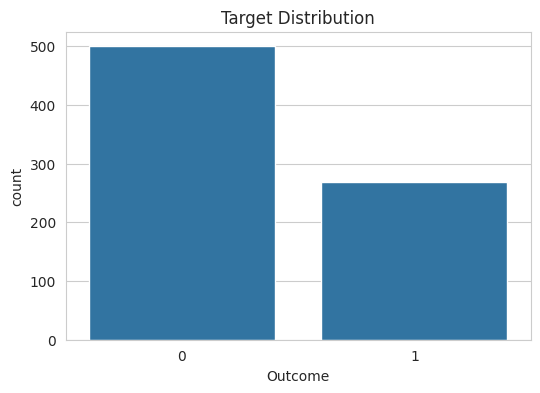

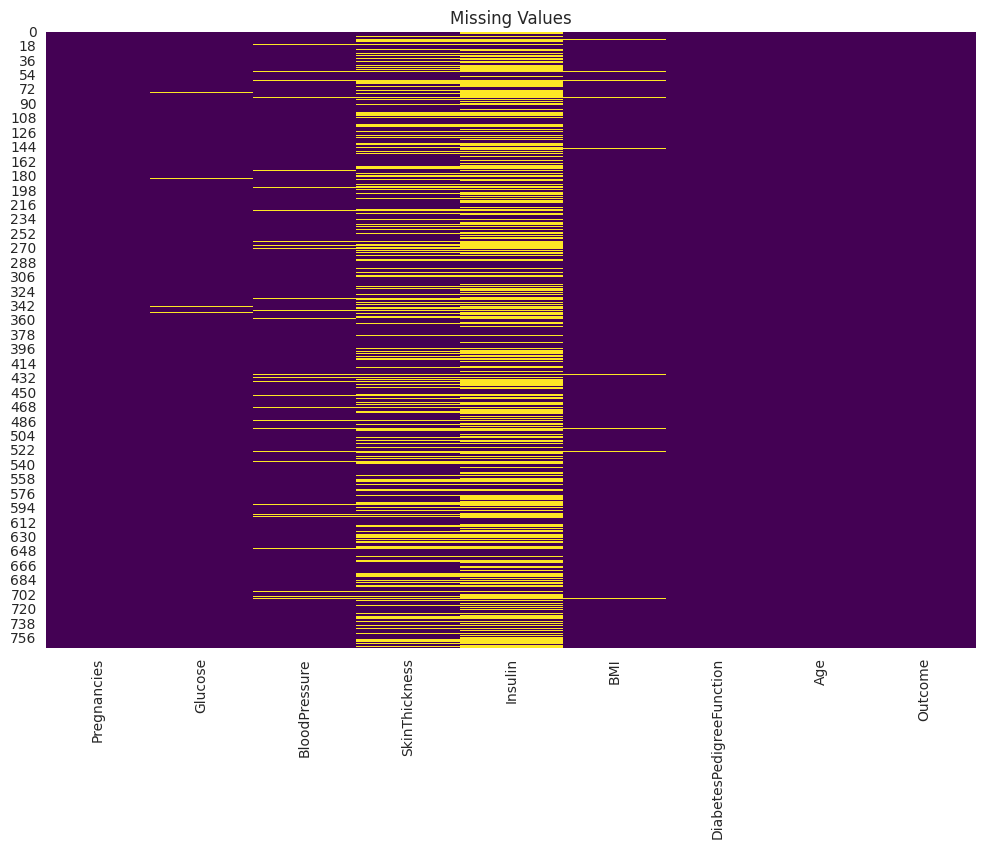

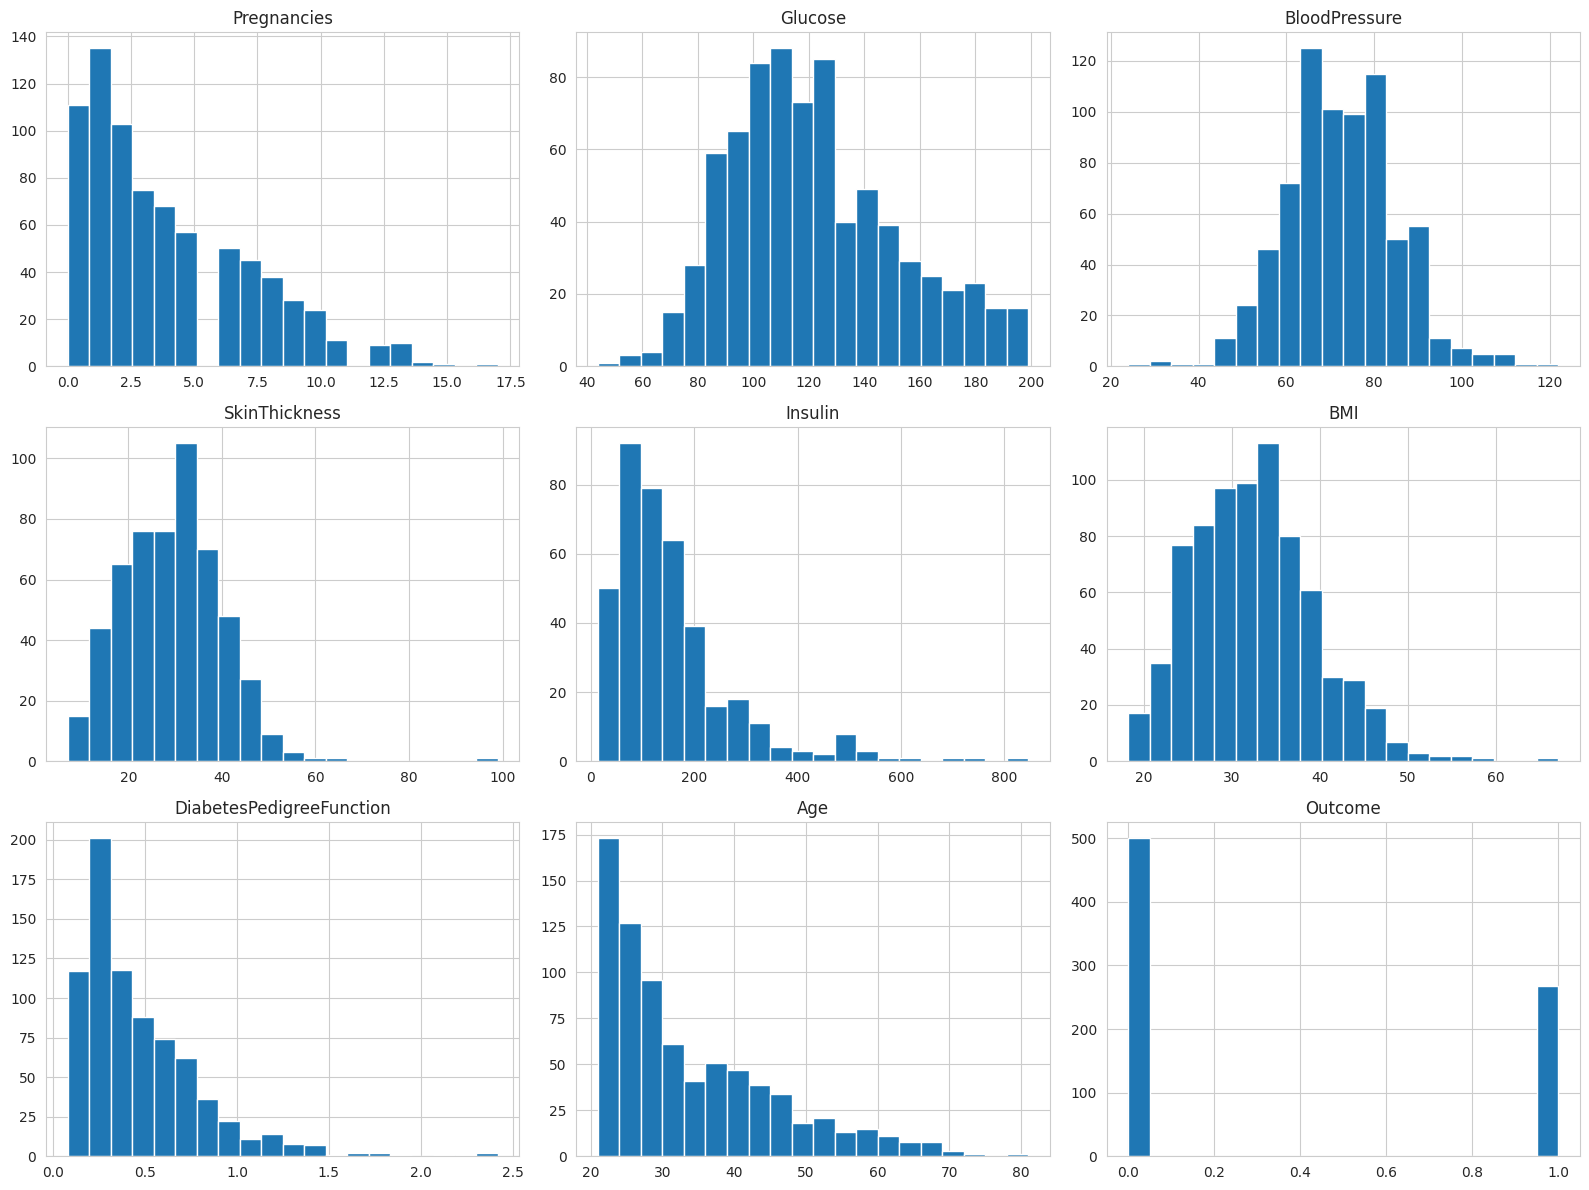

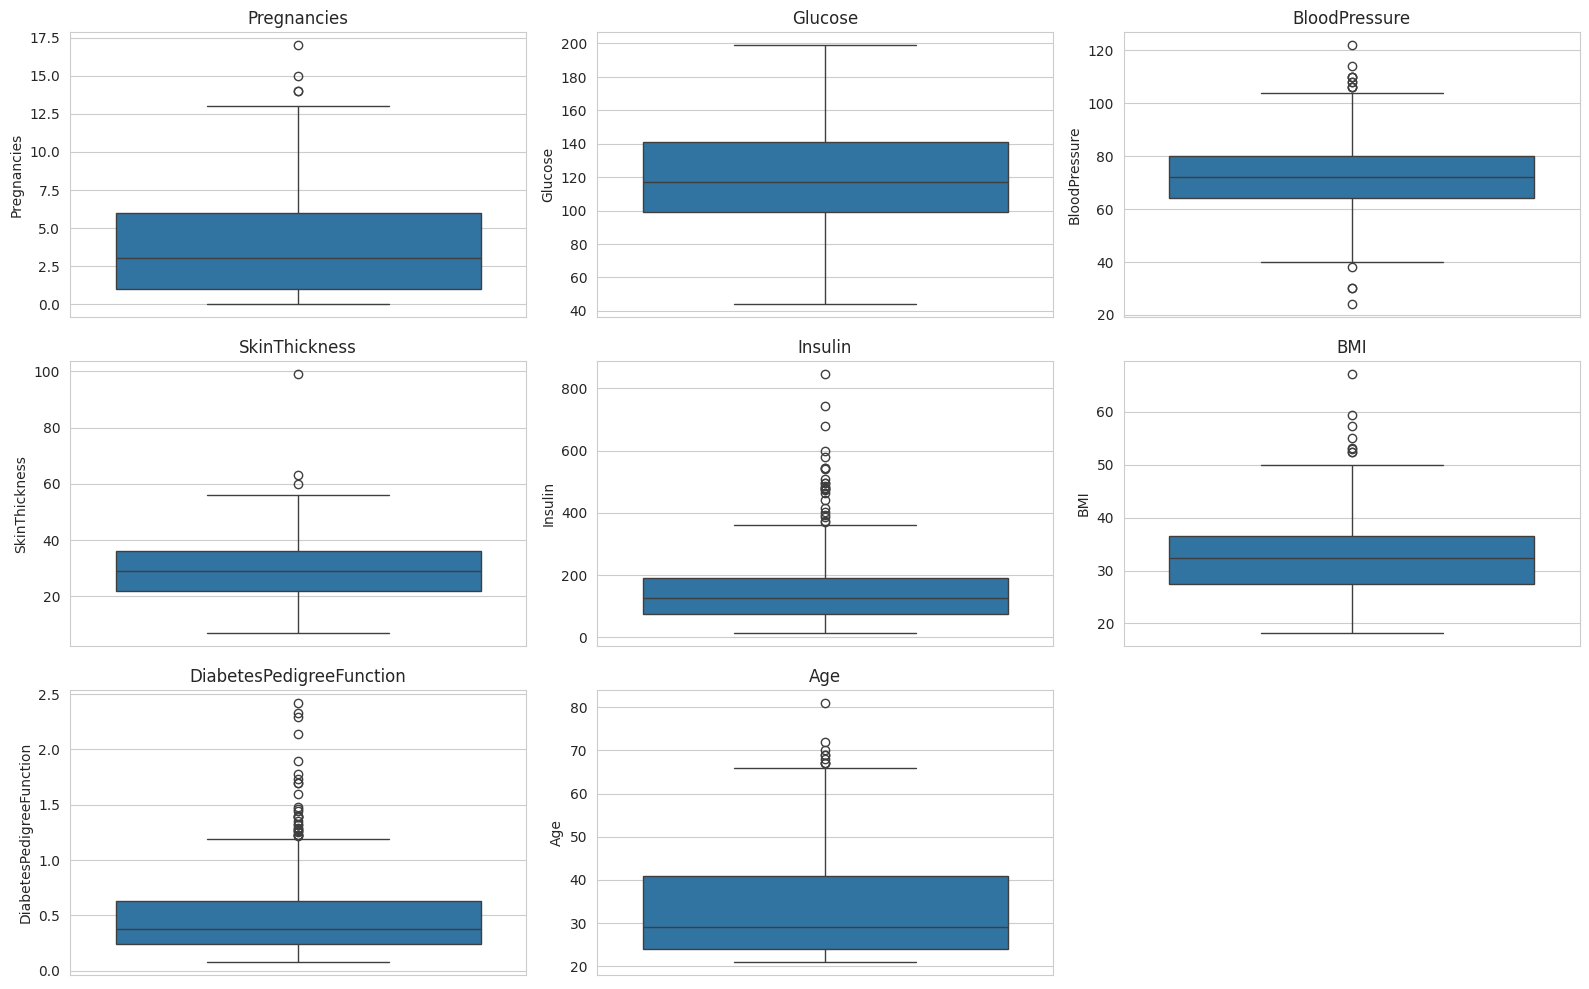

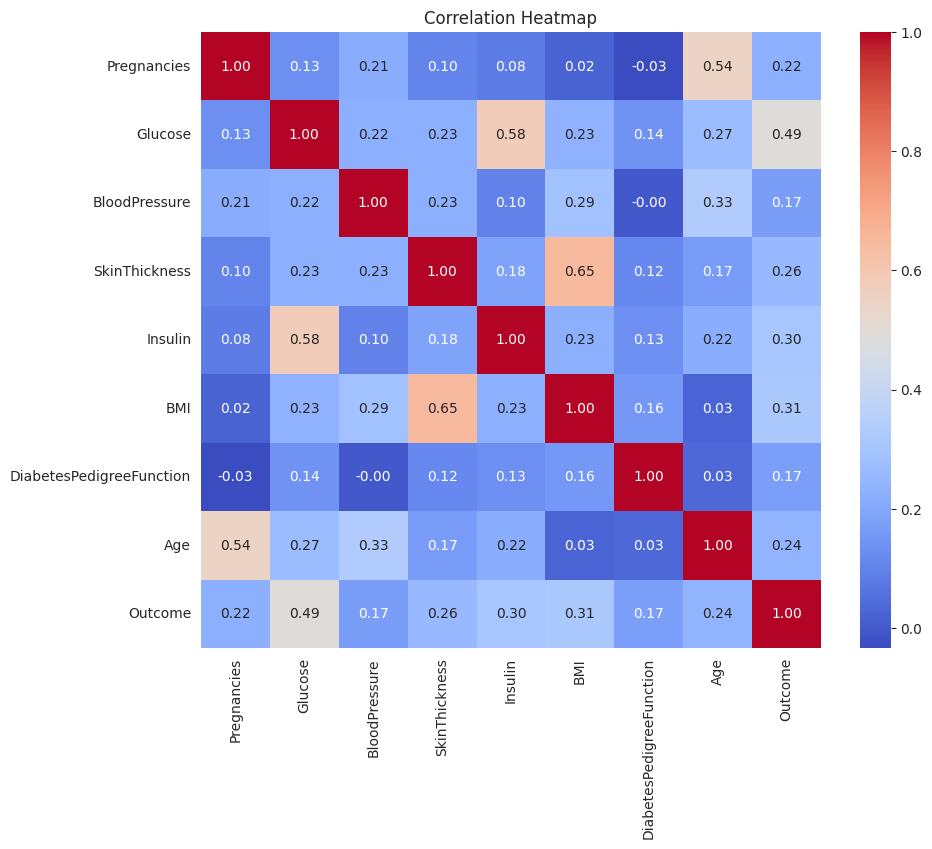

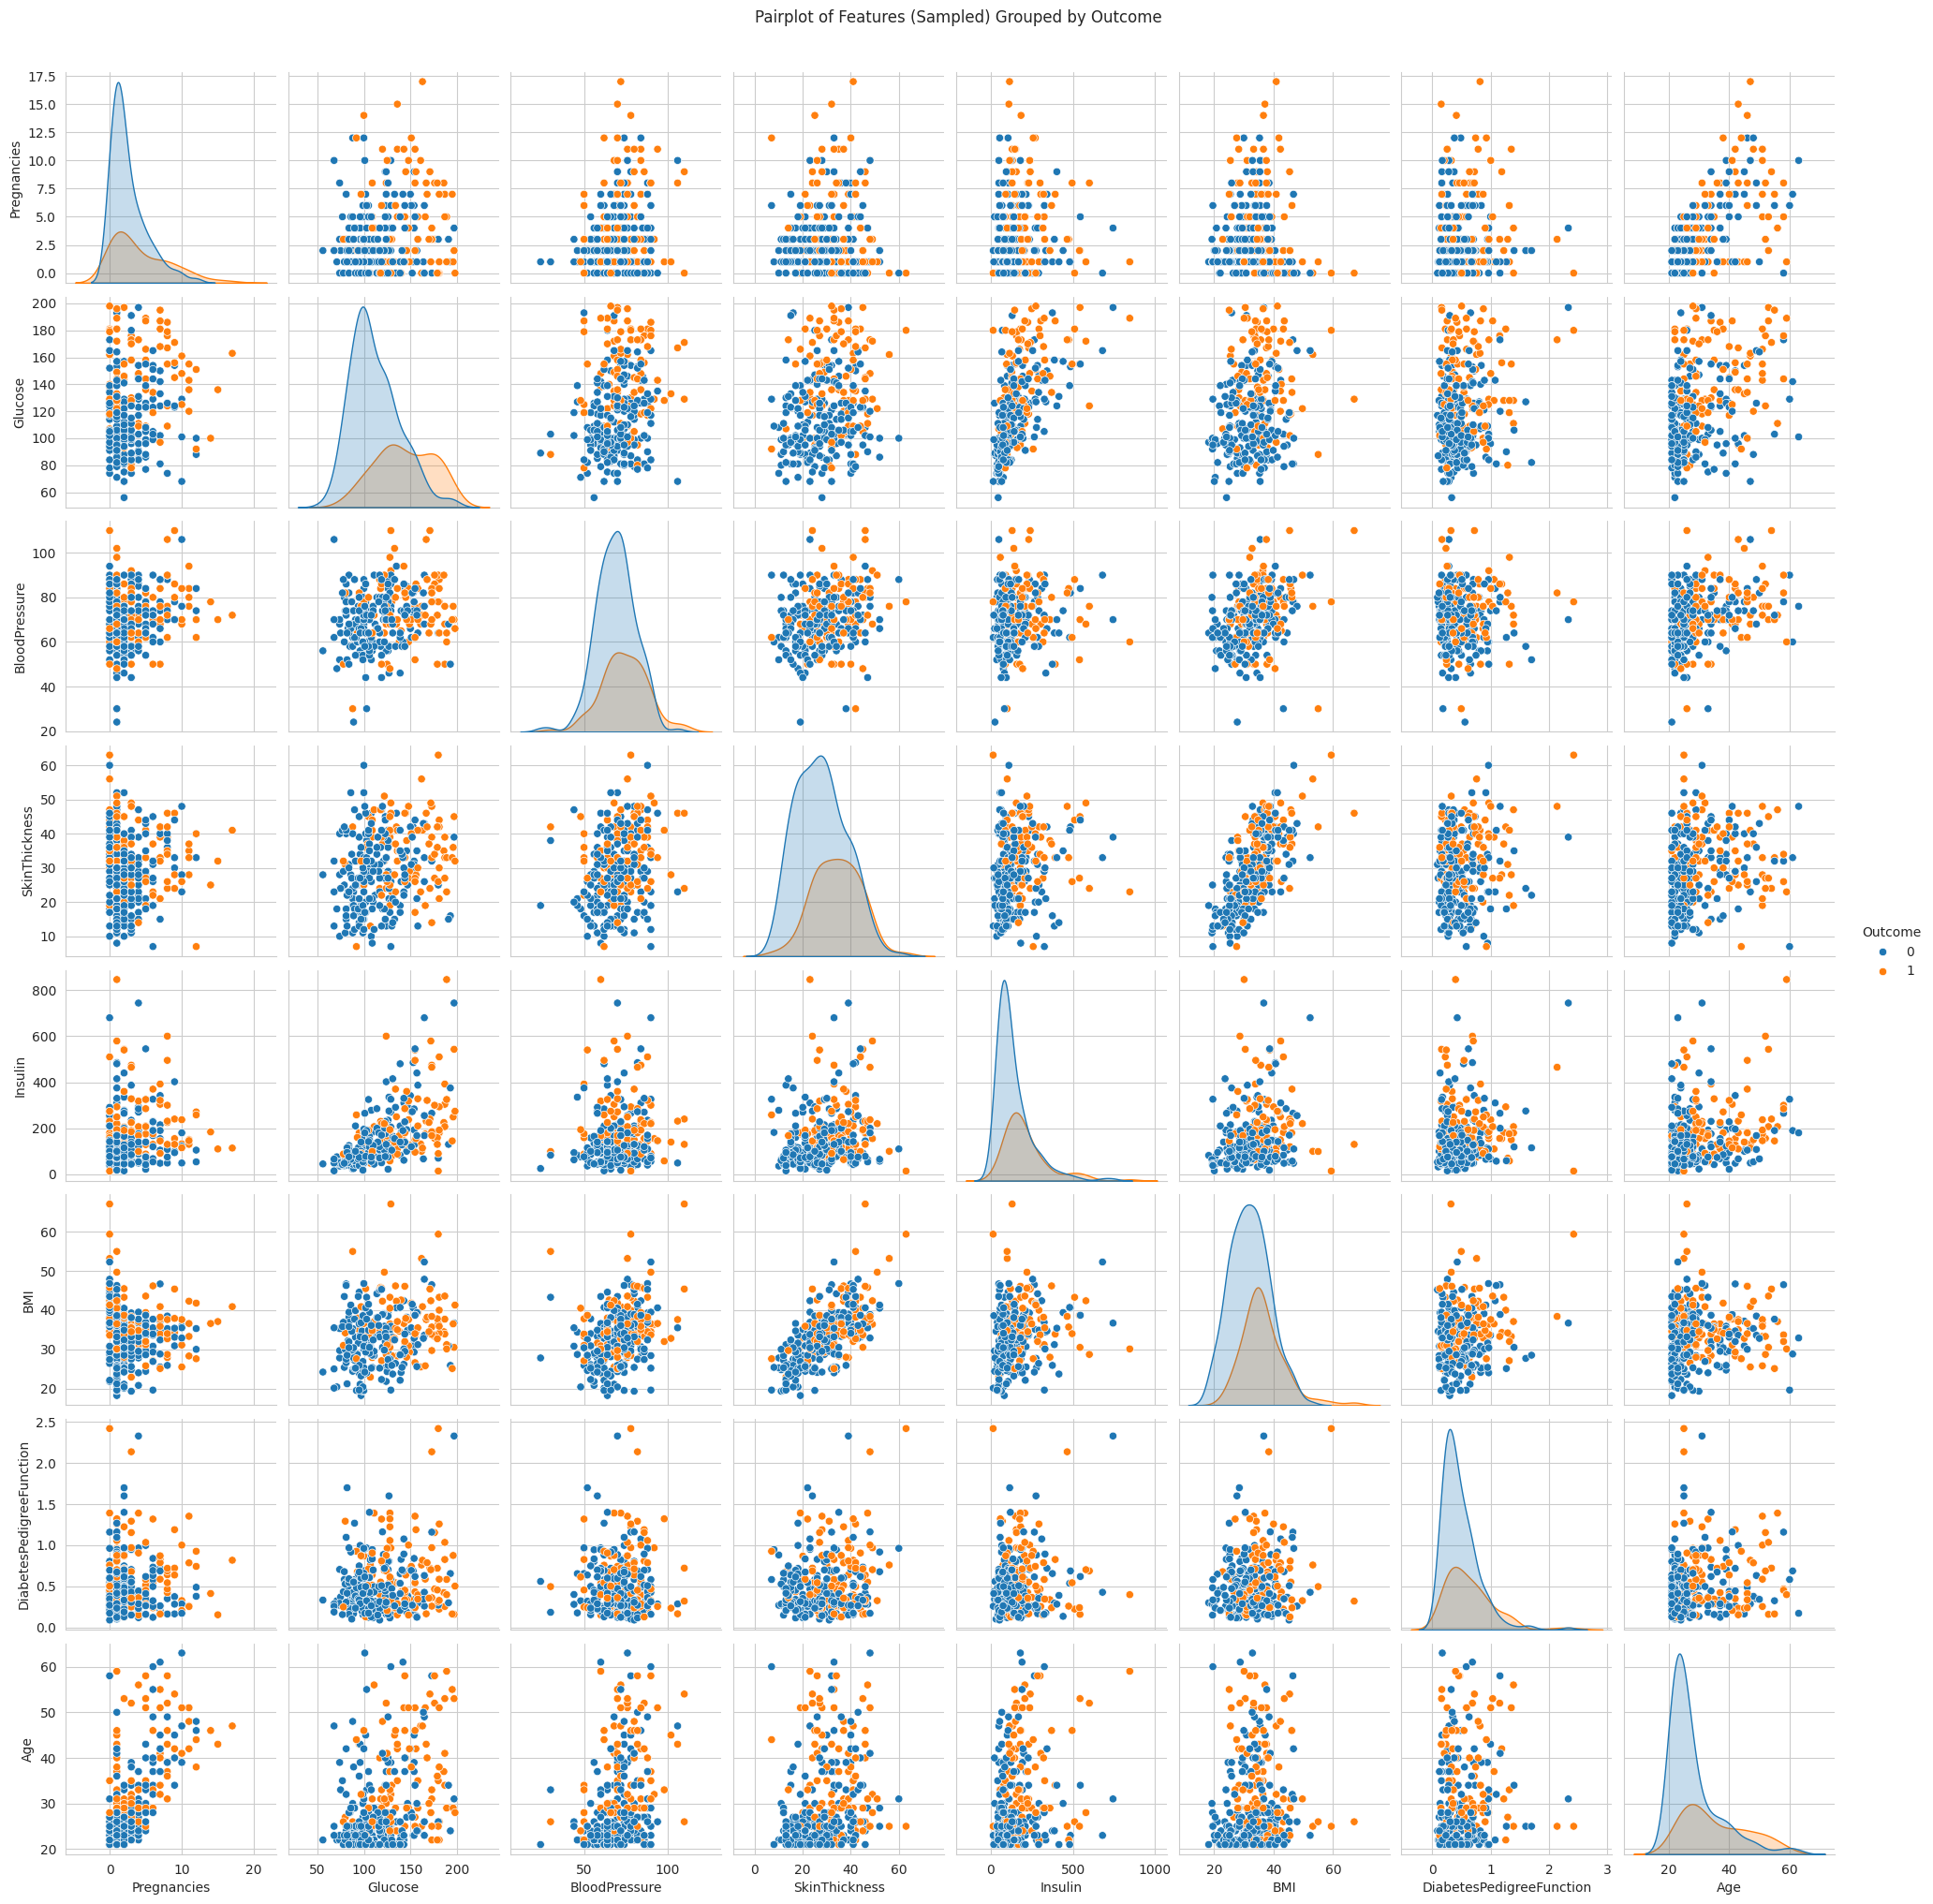

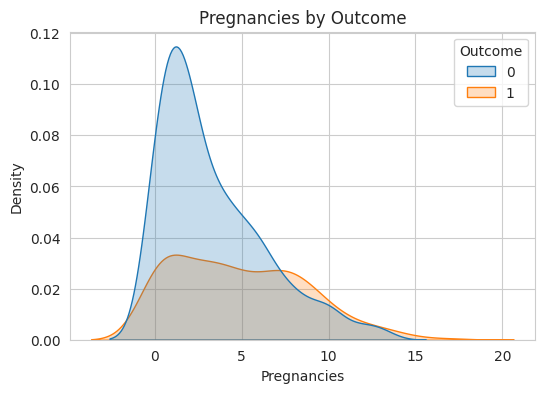

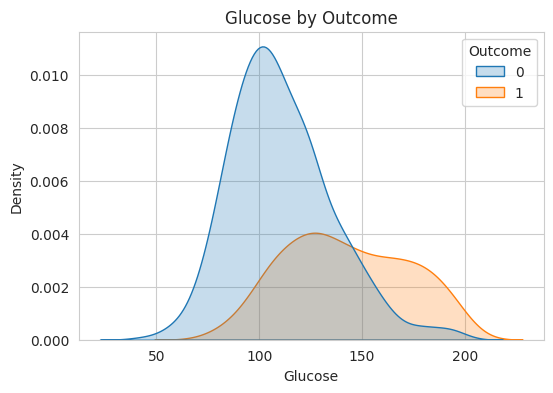

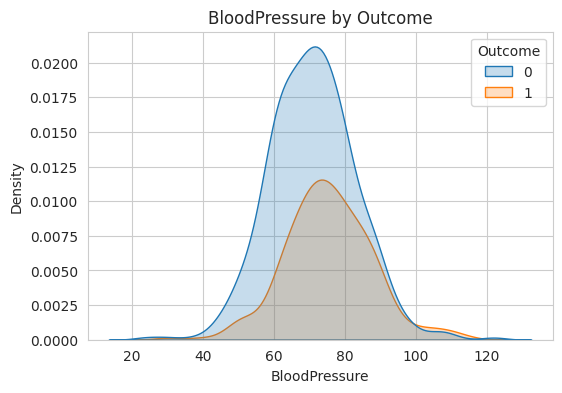

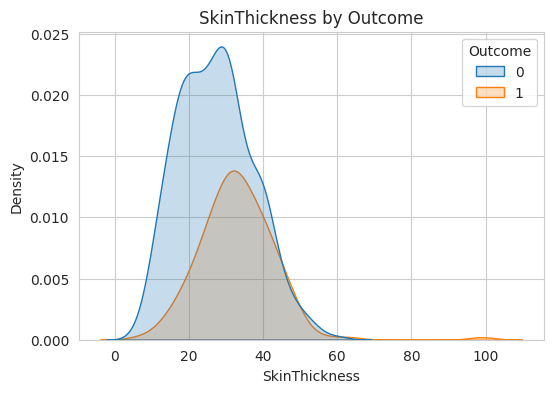

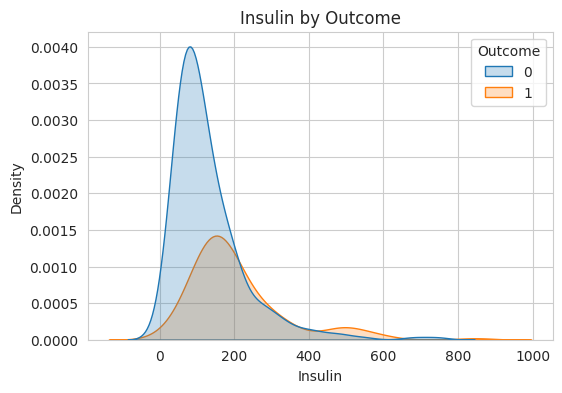

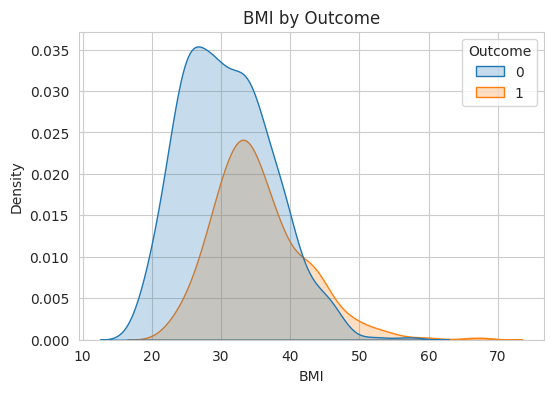

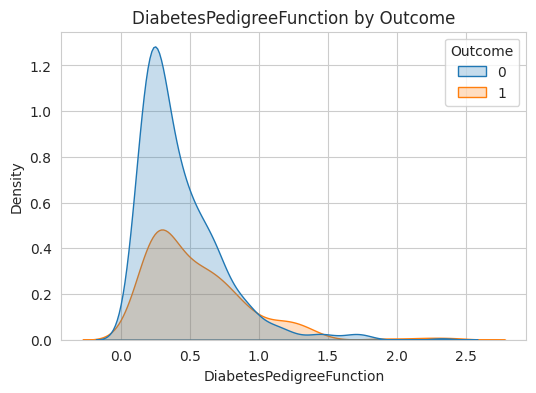

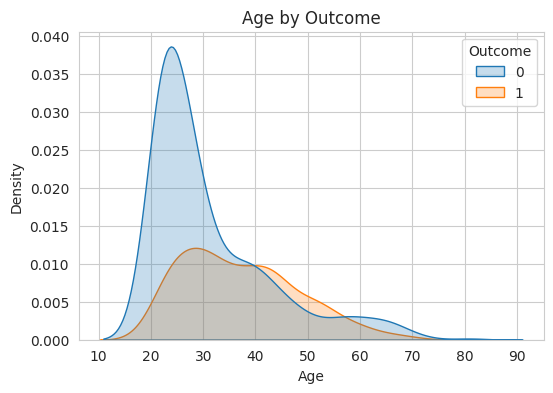

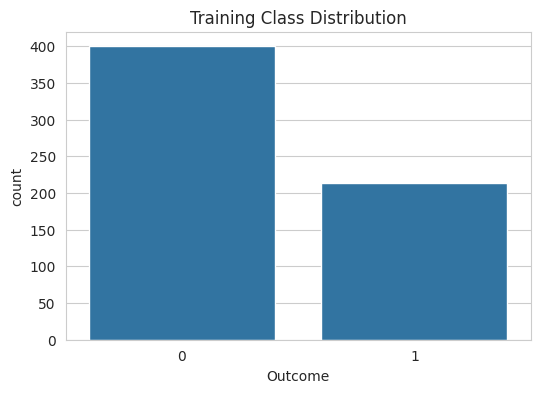


Class Distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Applying SMOTE...


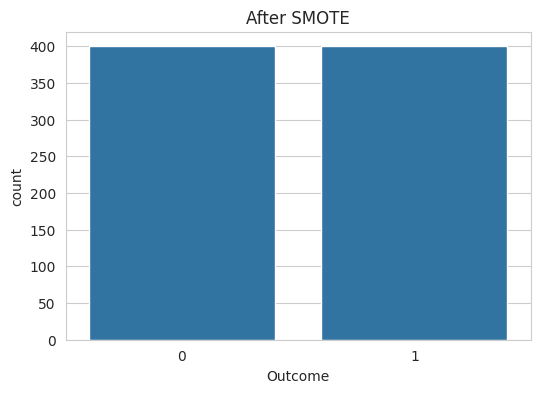

                 Model  Mean ROC-AUC       Std
1        Random Forest      0.902578  0.014582
5              XGBoost      0.888422  0.018357
2    Gradient Boosting      0.878375  0.014966
3                  SVM      0.872469  0.029157
4                  KNN      0.857062  0.025365
0  Logistic Regression      0.840875  0.022490


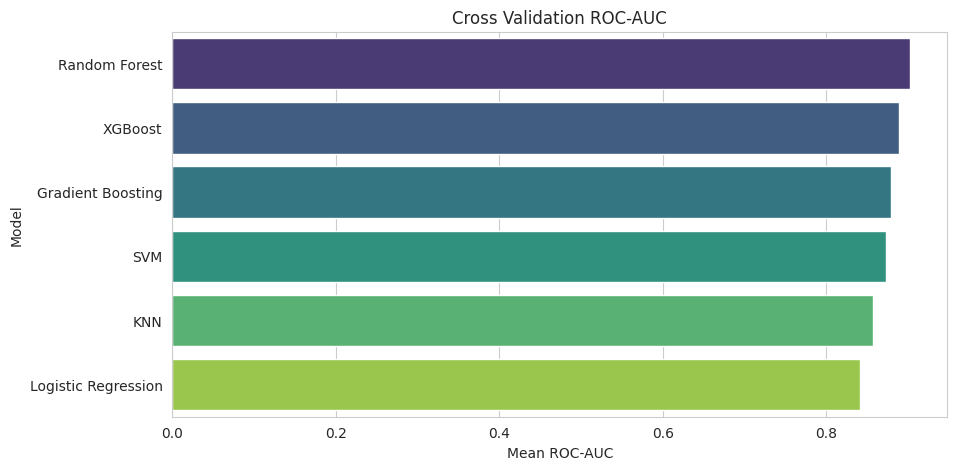


Best Model: Random Forest

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 10}

Best CV ROC-AUC:
0.898125

Accuracy : 0.7467532467532467
Precision: 0.6229508196721312
Recall   : 0.7037037037037037
F1 Score : 0.6608695652173913
ROC AUC  : 0.8274074074074074

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       100
           1       0.62      0.70      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



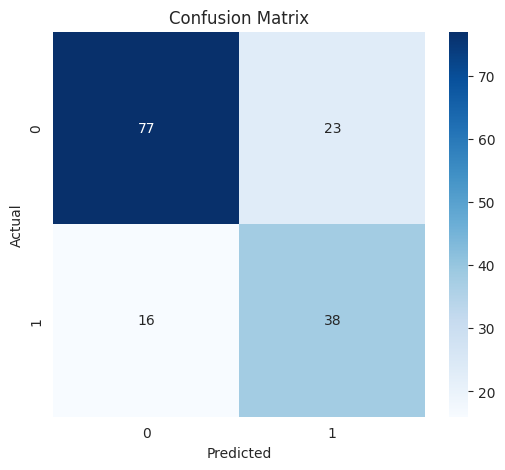

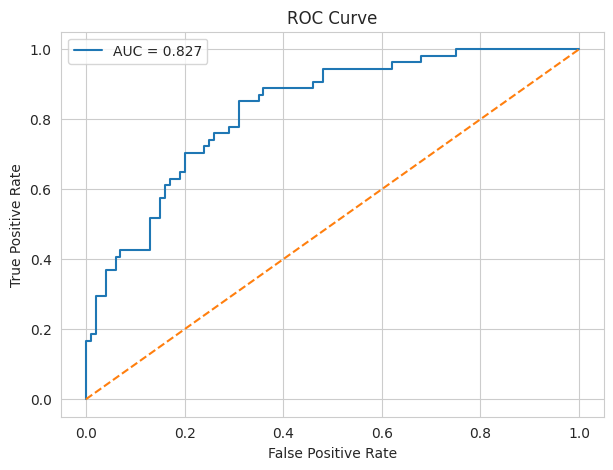

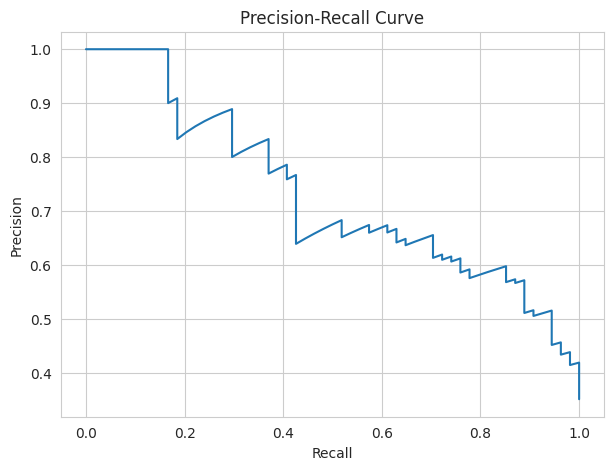

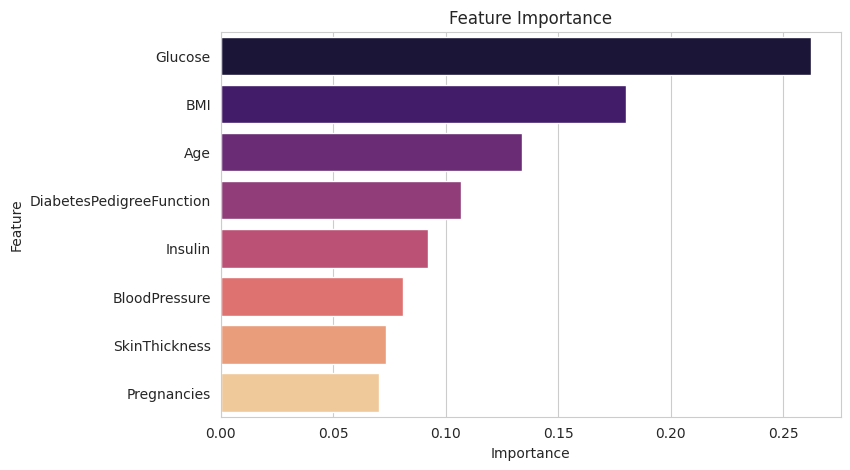


Final Summary
            Metric          Value
0       Best Model  Random Forest
1  Best CV ROC-AUC         0.8981
2    Test Accuracy         0.7468
3   Test Precision          0.623
4      Test Recall         0.7037
5          Test F1         0.6609
6     Test ROC-AUC         0.8274


In [37]:
# =========================
# Imports
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

sns.set_style("whitegrid")

# =========================
# Load Data
# =========================

# Construct the full file path
file_path = os.path.join(path, 'diabetes.csv')
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# =========================
# Data Cleaning
# =========================

cols_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in cols_with_zero:
    df[col] = df[col].replace(0, np.nan)

print("\nMissing Values After Zero Replacement:")
print(df.isnull().sum())

# =========================
# EDA
# =========================

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values")
plt.show()

df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16,10))
for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

sample_df = df.dropna().sample(
    min(300, len(df.dropna())),
    random_state=42
)

sns.pairplot(sample_df, hue="Outcome")
plt.suptitle('Pairplot of Features (Sampled) Grouped by Outcome', y=1.02)
plt.show()

for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="Outcome", fill=True)
    plt.title(f"{col} by Outcome")
    plt.show()

# =========================
# Features / Target
# =========================

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# =========================
# Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# Imputation
# =========================

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# =========================
# Class Balance Check
# =========================

plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Training Class Distribution")
plt.show()

print("\nClass Distribution:")
print(y_train.value_counts(normalize=True))

ratio = y_train.value_counts(normalize=True).min()

if ratio < 0.40:
    print("\nApplying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

    plt.figure(figsize=(6,4))
    sns.countplot(x=y_train)
    plt.title("After SMOTE")
    plt.show()

# =========================
# Models
# =========================

models = {
    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "SVM":
        SVC(probability=True, random_state=42),

    "KNN":
        KNeighborsClassifier()
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

# =========================
# Cross Validation
# =========================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    score = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    results.append([
        name,
        score.mean(),
        score.std()
    ])

cv_df = pd.DataFrame(
    results,
    columns=["Model", "Mean ROC-AUC", "Std"]
)

cv_df = cv_df.sort_values(
    by="Mean ROC-AUC",
    ascending=False
)

print(cv_df)

# =========================
# CV Comparison Plot
# =========================

plt.figure(figsize=(10,5))
sns.barplot(
    data=cv_df,
    x="Mean ROC-AUC",
    y="Model",
    palette="viridis"
)
plt.title("Cross Validation ROC-AUC")
plt.show()

# =========================
# Best Model
# =========================

best_model_name = cv_df.iloc[0]["Model"]

print("\nBest Model:", best_model_name)

# =========================
# Hyperparameter Tuning
# =========================

if best_model_name == "Random Forest":

    model = RandomForestClassifier(random_state=42)

    params = {
        "model__n_estimators":[100,200,300,500],
        "model__max_depth":[3,5,10,None],
        "model__min_samples_split":[2,5,10],
        "model__min_samples_leaf":[1,2,4]
    }

elif best_model_name == "XGBoost" and xgb_available:

    model = XGBClassifier(
        eval_metric="logloss",
        random_state=42
    )

    params = {
        "model__n_estimators":[100,200,300],
        "model__max_depth":[3,5,7],
        "model__learning_rate":[0.01,0.05,0.1],
        "model__subsample":[0.8,1.0]
    }

elif best_model_name == "Gradient Boosting":

    model = GradientBoostingClassifier(random_state=42)

    params = {
        "model__n_estimators":[100,200,300],
        "model__learning_rate":[0.01,0.05,0.1],
        "model__max_depth":[2,3,4]
    }

elif best_model_name == "SVM":

    model = SVC(probability=True)

    params = {
        "model__C":[0.1,1,10,100],
        "model__kernel":["linear","rbf"],
        "model__gamma":["scale","auto"]
    }

elif best_model_name == "KNN":

    model = KNeighborsClassifier()

    params = {
        "model__n_neighbors":[3,5,7,9,11],
        "model__weights":["uniform","distance"]
    }

else:

    model = LogisticRegression(max_iter=5000)

    params = {
        "model__C":[0.01,0.1,1,10,100],
        "model__penalty":["l2"]
    }

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model)
])

search = RandomizedSearchCV(
    pipe,
    params,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest Parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

# =========================
# Test Evaluation
# =========================

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# ROC Curve
# =========================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr,
         label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================
# Precision Recall Curve
# =========================

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# =========================
# Feature Importance
# =========================

model_obj = best_model.named_steps["model"]

if hasattr(model_obj, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model_obj.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    plt.figure(figsize=(8,5))
    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        palette="magma"
    )
    plt.title("Feature Importance")
    plt.show()

elif hasattr(model_obj, "coef_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": np.abs(model_obj.coef_[0])
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    plt.figure(figsize=(8,5))
    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature",
        palette="magma"
    )
    plt.title("Feature Importance")
    plt.show()

# =========================
# Final Summary
# =========================

summary = pd.DataFrame({
    "Metric":[
        "Best Model",
        "Best CV ROC-AUC",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC"
    ],
    "Value":[
        best_model_name,
        round(search.best_score_,4),
        round(accuracy,4),
        round(precision,4),
        round(recall,4),
        round(f1,4),
        round(roc_auc,4)
    ]
})

print("\nFinal Summary")
print(summary)
